<a href="https://colab.research.google.com/github/ViKing-Coder-jpg/CryptoMoon/blob/main/BackEnd/CryptoMoon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CryptoMoon -A Bitcoin Predictor


# Data Extraction and Library Importing

In [1]:
import sys
print(sys.executable)

!pip3 list

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/bin/python
Package                 Version
----------------------- ------------
annotated-doc           0.0.4
annotated-types         0.7.0
anyio                   4.12.1
appnope                 0.1.4
asttokens               3.0.1
beautifulsoup4          4.14.3
blinker                 1.9.0
certifi                 2026.2.25
cffi                    2.0.0
charset-normalizer      3.4.6
click                   8.3.1
comm                    0.2.3
contourpy               1.3.3
curl_cffi               0.13.0
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fastapi                 0.135.1
fonttools               4.62.1
frozendict              2.4.7
h11                     0.16.0
httpcore                1.0.9
httpx                   0.28.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.11.0
ipython_pygments_lexers 1.1.1
itsdang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error

In [3]:
import kagglehub
path = kagglehub.dataset_download("aiwithcagri/bitcoin-12-years-price-january-2026")
data= pd.read_csv(path+'/bitcoin (1).csv')
data.shape

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4134, 6)

#Data Cleaning and Preprocessing

In [4]:
print('Empty Cells:',data.isna().sum().sum())
data['Date']=pd.to_datetime(data['Date'])
data.sort_values('Date',inplace=True)
data['Close'].median()


Empty Cells: 0


np.float64(10795.1455078125)

#Feature Engineering and train-test splitting

In [ ]:
# Use the same feature pipeline as production. The Target column is now the
# 5-day cumulative forward return: (Close[t+5] / Close[t]) - 1.
import os, sys
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
BACKEND_DIR = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == "Model" else NOTEBOOK_DIR
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

from Controllers.feature_creation import feature_conversion
from Controllers.external_signals import load_external_signals
from Model.train import load_cross_assets, FORECAST_HORIZON_DAYS

cross_assets_df = load_cross_assets()
external_signals_df = load_external_signals()
print('cross_assets:', None if cross_assets_df is None else len(cross_assets_df), 'rows')
print('external_signals:', None if external_signals_df is None else len(external_signals_df), 'rows')
print('forecast horizon (days):', FORECAST_HORIZON_DAYS)

featData = feature_conversion(data, cross_assets=cross_assets_df, external_signals=external_signals_df)
featData['Target'] = (featData['Close'].shift(-FORECAST_HORIZON_DAYS) / featData['Close']) - 1.0
featData.drop(columns=['Date', 'Close'], inplace=True, errors='ignore')
featData.dropna(inplace=True)
featData.reset_index(drop=True, inplace=True)
print('feature columns:', list(featData.columns))
featData.head()


In [6]:
y = featData['Target']
X = featData.drop('Target', axis=1)
print('X shape:', X.shape, '| y shape:', y.shape)


X shape: (4083, 18) | y shape: (4083,)


In [7]:
print(X.columns.tolist())
joblib.dump(X.columns.tolist(), 'feature_names.joblib')


['MACD', 'RSI', 'Returns', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'MACD_histogram', 'Volume_change', 'Volume_SMA_20_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Volatility_5', 'Volatility_10', 'HL_Range_pct', 'OC_Range_pct', 'Close_EMA20_diff']


['feature_names.joblib']

In [ ]:
# Walk-Forward Validation + RandomizedSearchCV via the reusable training pipeline.
from Model.train import train_walk_forward, save_artifacts, seed_history_csv
from Controllers.online_learning import seed_cross_assets
from Controllers.external_signals import seed_external_signals

# 1. BTC OHLCV tape (used by online_learning.append_new_observation()).
seed_path = seed_history_csv(data)
print(f'Seeded BTC tape: {seed_path}')

# 2. Cross-asset tape (ETH/SPY/UUP/GLD).
btc_dates = pd.to_datetime(data['Date'])
start = btc_dates.min().strftime('%Y-%m-%d')
end = (btc_dates.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
print(f'Seeding cross-asset tape ({start} -> {end})...')
print(seed_cross_assets(start, end))

# 3. External signals tape (Fear & Greed + Blockchain.com on-chain + Binance funding).
print('Seeding external-signals tape...')
print(seed_external_signals())

# 4. Train (walk-forward + RandomizedSearchCV with the direction-aware scorer).
result = train_walk_forward(data)
paths = save_artifacts(result)

print('\nBest hyperparameters:')
for k, v in result.best_params.items():
    print(f'  {k:<20s} {v}')

print('\nBaseline walk-forward summary (default hyperparameters):')
for k, v in result.extras['baseline_summary'].items():
    print(f'  {k:<30s} {v:.6f}')

print('\nTuned walk-forward summary:')
for k, v in result.extras['tuned_summary'].items():
    print(f'  {k:<30s} {v:.6f}')

print('\nPer-fold metrics (tuned):')
print(result.fold_metrics.to_string(index=False))

print('\nArtifacts saved:')
for k, v in paths.items():
    print(f'  {k}: {v}')


# Model Training and Testing
  Using XGBoost as Base ML Model



In [9]:
# Re-derive y_test / y_pred from the LAST walk-forward fold so the
# downstream visualisation + backtest cells continue to work unchanged.
from sklearn.model_selection import TimeSeriesSplit

splits = list(TimeSeriesSplit(n_splits=10).split(X))
train_idx, test_idx = splits[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Fit a fresh model with the tuned hyperparameters for visualisation only
# (no early stopping here; we just want predictions on the held-out tail).
viz_params = dict(result.best_params)
viz_params.pop('early_stopping_rounds', None)
model = XGBRegressor(**viz_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Visualisation hold-out size:', len(test_idx))


Visualisation hold-out size: 371


In [10]:
# The production model was already persisted by save_artifacts() above.
# Read back the metadata for transparency.
import json
metadata_path = os.path.join(BACKEND_DIR, 'Model', 'model_metadata.json')
with open(metadata_path) as fh:
    metadata = json.load(fh)
print(json.dumps(metadata, indent=2))


{
  "trained_through": "2026-01-10",
  "n_train_rows": 4083,
  "hyperparameters": {
    "subsample": 0.8,
    "reg_lambda": 1.0,
    "reg_alpha": 1.0,
    "n_estimators": 400,
    "min_child_weight": 3,
    "max_depth": 2,
    "learning_rate": 0.01,
    "colsample_bytree": 0.8,
    "objective": "reg:pseudohubererror"
  },
  "baseline_summary": {
    "rmse_mean": 0.036813869827899616,
    "rmse_std": 0.011201734762026374,
    "mae_mean": 0.025904723907893463,
    "dir_acc_mean": 0.5059299191374662,
    "dir_acc_filtered_mean": 0.5028177346465761
  },
  "tuned_summary": {
    "rmse_mean": 0.03399441902167019,
    "rmse_std": 0.008968355426476114,
    "mae_mean": 0.023163154636358155,
    "dir_acc_mean": 0.5226415094339623,
    "dir_acc_filtered_mean": 0.5408986797542612
  },
  "search_best_neg_rmse": -0.03479050550134792,
  "feature_names": [
    "MACD",
    "RSI",
    "Returns",
    "Close_SMA20_Ratio",
    "Close_SMA50_Ratio",
    "MACD_histogram",
    "Volume_change",
    "Volume_SMA_

In [ ]:
# ----- Sanity check: persistence baseline -----
# A persistence model just predicts that today's return = yesterday's return.
# If the XGBoost model can't beat this on direction accuracy, the model isn't
# adding signal beyond simple autocorrelation.
from sklearn.metrics import root_mean_squared_error

baseline_pred = X_test['Lag_1'].to_numpy()
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
baseline_dir_acc = float(((baseline_pred > 0) == (y_test.values > 0)).mean())

model_rmse = root_mean_squared_error(y_test, y_pred)
model_dir_acc = float(((y_pred > 0) == (y_test.values > 0)).mean())

import pandas as pd
print(pd.DataFrame({
    'rmse':         [baseline_rmse, model_rmse],
    'dir_acc':      [baseline_dir_acc, model_dir_acc],
    'pred_std':     [baseline_pred.std(), y_pred.std()],
    'pred_mean':    [baseline_pred.mean(), y_pred.mean()],
}, index=['persistence (Lag_1)', 'XGBoost']).to_string())


In [ ]:
# ----- Permutation feature importance on the held-out fold -----
# Drop the columns near the bottom in the next iteration -- they hurt or do nothing.
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('Top 10 features:')
print(imp.head(10).to_string())
print('\nBottom 5 features:')
print(imp.tail(5).to_string())


Filtered Accuracy: 0.5
Trade %: 0.05390835579514825


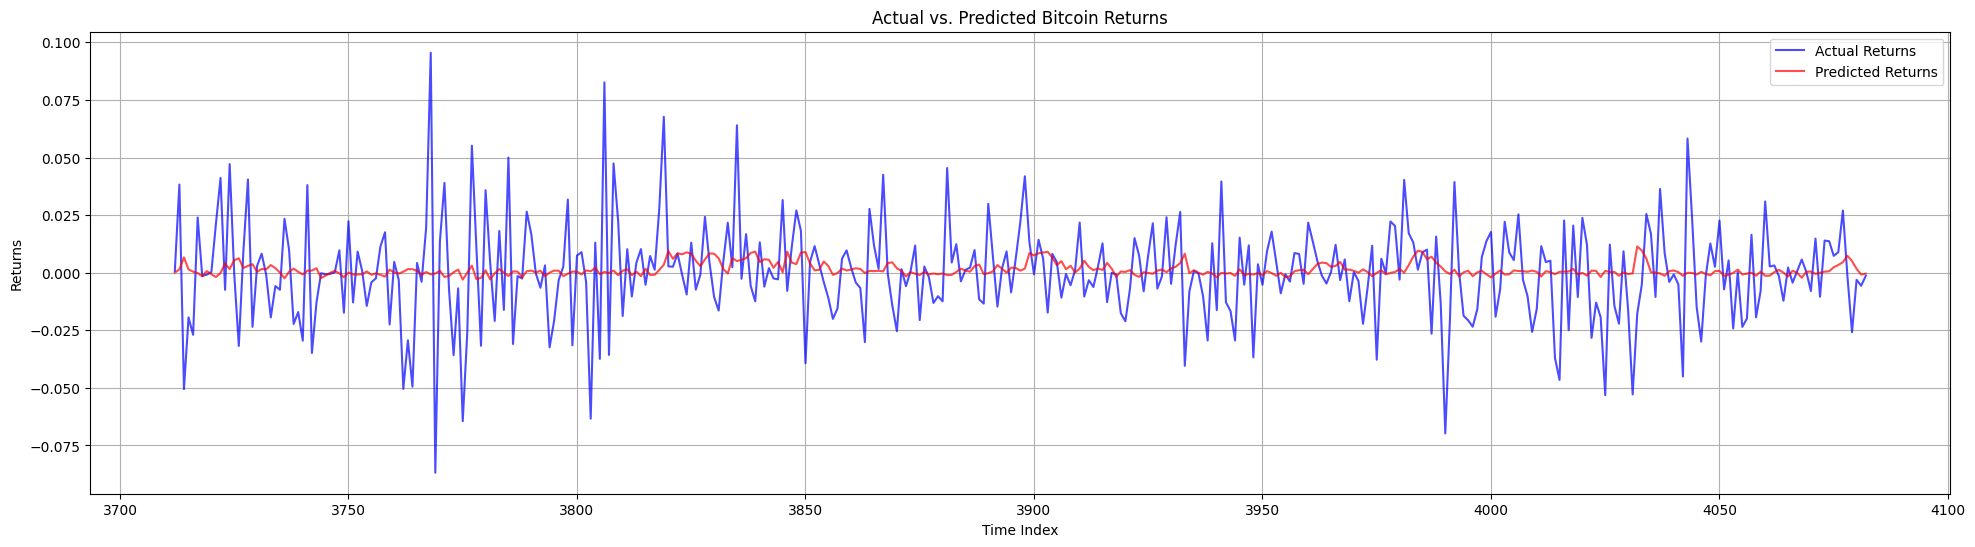

In [11]:
threshold = 0.008

signals = np.where(y_pred > threshold, 1,
          np.where(y_pred < -threshold, -1, 0))

mask = signals != 0

direction_acc = np.mean((signals[mask] > 0) == (y_test[mask] > 0))

print("Filtered Accuracy:", direction_acc)
print("Trade %:", np.mean(mask))


plt.figure(figsize=(24, 6))
plt.plot(y_test.index, y_test, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()


Direction Accuracy:     50.40%
Sharpe Ratio:           0.009
Max Drawdown:           -32.15%
Final Strategy Return:  0.919x
Final Market Return:    0.920x


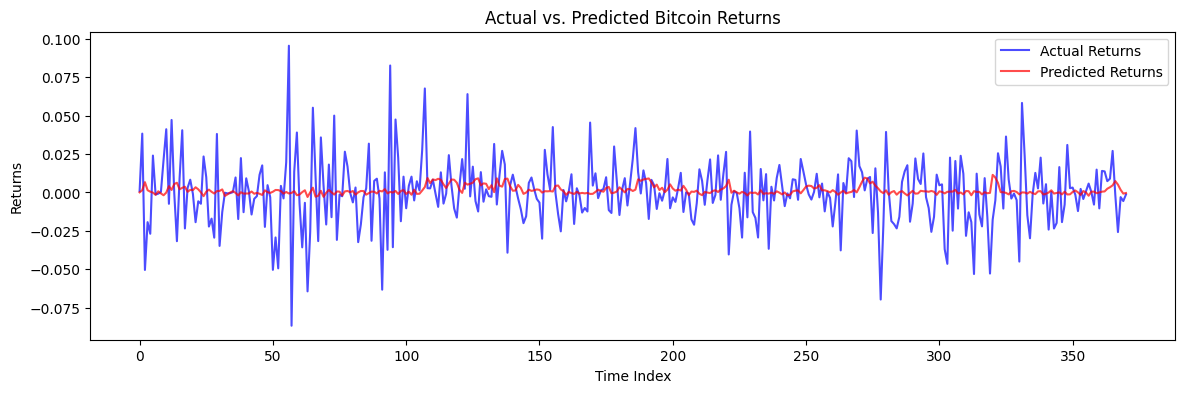

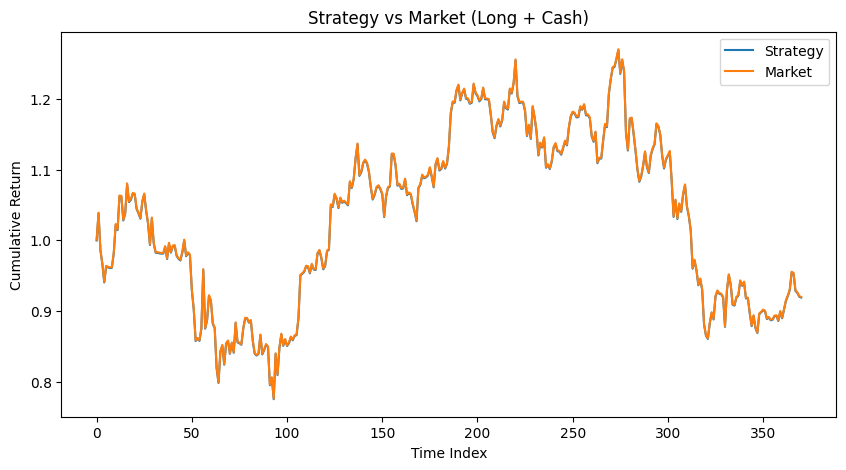

In [12]:
threshold_enter = 0.001
threshold_exit = -0.025   # exit to cash if pred < this
                          # between the two = hold current position

position = np.zeros(len(y_pred))
current_pos = 1  # start invested

for i in range(len(y_pred)):
    if y_pred[i] > threshold_enter:
        current_pos = 1   # go/stay long
    elif y_pred[i] < threshold_exit:
        current_pos = 0   # exit to cash
    position[i] = current_pos

# Apply returns
strategy_returns = position * y_test.values

# Transaction cost only when position changes
trades = np.abs(np.diff(position, prepend=0))
cost = 0.001
strategy_returns = strategy_returns - cost * trades

# Cumulative
cumulative_strategy = pd.Series((1 + strategy_returns).cumprod())
cumulative_market = pd.Series((1 + y_test.values).cumprod())

# ----------------------------------------
# METRICS
# ----------------------------------------
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365)
drawdown = (cumulative_strategy / cumulative_strategy.cummax() - 1).min()
direction_acc = np.mean((y_pred > 0) == (y_test.values > 0))

print(f"Direction Accuracy:     {direction_acc:.2%}")
print(f"Sharpe Ratio:           {sharpe:.3f}")
print(f"Max Drawdown:           {drawdown:.2%}")
print(f"Final Strategy Return:  {cumulative_strategy.iloc[-1]:.3f}x")
print(f"Final Market Return:    {cumulative_market.iloc[-1]:.3f}x")

# ----------------------------------------
# PLOT 1 - Actual vs Predicted Returns
# ----------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(y_test.values, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.show()

# ----------------------------------------
# PLOT 2 - Strategy vs Market
# ----------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(cumulative_strategy, label='Strategy')
plt.plot(cumulative_market, label='Market')
plt.legend()
plt.title('Strategy vs Market (Long + Cash)')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Return')
plt.show()